In [1]:
import cv2
import numpy as np
from scipy.fftpack import dct

def compute_frequency_feature_map(input_img, rectified_img):

    delta_I = input_img.astype(np.float32) - rectified_img.astype(np.float32)
    freq_map = []

    for c in range(delta_I.shape[2]):
        channel = delta_I[:, :, c]

        dct_channel = dct(
            dct(channel.T, norm='ortho').T,
            norm='ortho'
        )

        freq_map.append(dct_channel)

    freq_map = np.stack(freq_map, axis=-1)

    return freq_map

In [2]:
import sys
import os
# sys.path.append('/content/trapdoor/trapdoor/')
sys.path.append(os.path.abspath('./trapdoor/trapdoor/'))

import numpy as np
import keras
import keras.backend as K
import tensorflow as tf
import matplotlib
matplotlib.use('Agg') # Set backend for non-interactive plotting
import matplotlib.pyplot as plt
tf.compat.v1.disable_eager_execution()

from trap_utils import load_dataset, preprocess, init_gpu

# sys.path.append('/content/')
sys.path.append(os.path.abspath('./'))

Using TensorFlow backend.


In [3]:
import os
# This explicitly hides all GPUs from TensorFlow
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
import keras.backend as K

# Verify TensorFlow is strictly on the CPU
from tensorflow.python.client import device_lib
devices = [x.name for x in device_lib.list_local_devices()]
print(f"TensorFlow is using: {devices}")

TensorFlow is using: ['/device:CPU:0', '/device:XLA_CPU:0']


In [4]:
from keras.layers import Input, Conv2D, Activation, Add, Lambda
import keras.backend as K
from keras.models import Model

def PRN(input_shape=(32, 32, 3)):
    """Builds the PRN in Keras."""
    inputs = Input(shape=input_shape)
    
    x = Conv2D(64, kernel_size=3, strides=1, padding='same', activation='relu')(inputs)
    
    for i in range(5):
        residual = x
        x = Conv2D(64, kernel_size=3, strides=1, padding='same', activation='relu')(x)
        x = Conv2D(64, kernel_size=3, strides=1, padding='same')(x)
        x = Add()([x, residual])
        x = Activation('relu')(x)
        
    x = Conv2D(16, kernel_size=3, strides=1, padding='same', activation='relu')(x)
    noise_mask = Conv2D(3, kernel_size=3, strides=1, padding='same')(x)
    rectified = Add()([inputs, noise_mask])
    outputs = Lambda(lambda x: K.clip(x, 0.0, 1.0))(rectified)
    
    return Model(inputs, outputs, name="PRN")

prn = PRN(input_shape=(32, 32, 3))

In [5]:
BATCH_SIZE = 64
LEARNING_RATE = 0.01
MAX_EPOCH = 10

In [6]:
import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

Num GPUs Available:  0


In [7]:
# ---- Environment setup ----
tf.compat.v1.set_random_seed(1234)
np.random.seed(1234)

MODEL_PATH = "results/cifar_res.p"
import os
import pickle

with open(MODEL_PATH, 'rb') as file:
    protected_model_data = pickle.load(file)

# Extract the actual model file path
MODEL_FILE = protected_model_data['model_file']
print(f'Loading honeypot model from: {MODEL_FILE}')

# FIRST initialize session
sess = init_gpu("0")
K.set_learning_phase(0)

# THEN load model into that session
model = keras.models.load_model(MODEL_FILE, compile=False)


train_X, train_Y, test_X, test_Y = load_dataset('cifar')  # or cifar
train_X = preprocess(train_X, method='raw')
test_X = preprocess(test_X, method='raw') # Added preprocessing for test_X

# Use a subset (UAPs do NOT need full dataset)
# train_X = train_X[:2000]

# Pre-softmax logits
if model.layers[-1].activation.__name__ == 'softmax':
    # No explicit pre-softmax tensor available
    logits = model.output
else:
    logits = model.layers[-1].input

input_tensor = model.input

# Gradient of logits w.r.t. input
grad_tensor = K.gradients(logits, input_tensor)[0]

############ Function Defs ############
# max_passes=40
def compute_universal_perturbation(
    X,
    grad_fn,
    pred_fn,
    xi=5.0,
    delta=0.2,
    max_passes=1):
    v = np.zeros_like(X[0])

    for epoch in range(max_passes):
        fooled = 0
        np.random.shuffle(X)
        for x in X:
            pred_clean = np.argmax(pred_fn([x[None]])[0])
            pred_adv = np.argmax(pred_fn([(x + v)[None]])[0])

            if pred_clean != pred_adv:
                fooled += 1
                continue

            dv = deepfool_step(x, v, grad_fn, pred_fn)
            v = project_l2(v + dv, xi)

        fooling_rate = fooled / float(len(X))
        print('Pass {} – Fooling rate: {:.3f}'.format(epoch, fooling_rate))

        if fooling_rate >= (1 - delta):
            break

    return v

def deepfool_step(x, v, grad_fn, pred_fn):
    x_adv = x + v
    logits = pred_fn([x_adv[None]])[0]
    label = np.argmax(logits)

    grads = grad_fn([x_adv[None]])[0][0]

    grad_norm = np.linalg.norm(grads) + 1e-8
    direction = grads / grad_norm

    step_size = 1e-3  # small, stable
    return step_size * direction

def project_l2(v, xi):
    norm = np.linalg.norm(v.ravel(), ord=2)
    if norm > xi:
        v = v * (xi / norm)
    return v

def show_original_vs_uap(x, v, i, title_left='Original', title_right='UAP Perturbed'):

    # Apply universal perturbation
    x_adv = x + v

    # Clip to valid range
    x_adv = np.clip(x_adv, 0.0, 1.0)

    plt.figure(figsize=(8, 4))

    # Original image
    plt.subplot(1, 2, 1)
    if x.shape[-1] == 1:  # MNIST
        plt.imshow(x[:, :, 0], cmap='gray')
    else:  # CIFAR
        plt.imshow(x)
    plt.title(title_left)
    plt.axis('off')

    # Perturbed image
    plt.subplot(1, 2, 2)
    if x_adv.shape[-1] == 1:
        plt.imshow(x_adv[:, :, 0], cmap='gray')
    else:  # CIFAR
        plt.imshow(x_adv)
    plt.title(title_right)
    plt.axis('off')

    plt.tight_layout()
    plt.savefig('original_vs_uap_{}.png'.format(i)) # Save the figure
    plt.close() # Close the figure to free up memory

def show_perturbation(v, i):
    v_vis = v - v.min()
    v_vis = v_vis / (v_vis.max() + 1e-8)

    plt.figure(figsize=(3, 3))
    if v.shape[-1] == 1:
        plt.imshow(v_vis[:, :, 0], cmap='gray')
    else:
        plt.imshow(v_vis)
    plt.title('Universal Perturbation_{} (scaled)'.format(i))
    plt.axis('off')
    plt.savefig('universal_perturbation_{}.png'.format(i)) # Save the figure
    plt.close() # Close the figure to free up memory

def generate_real_uaps(
    X,
    model,
    grad_fn,
    pred_fn,
    num_uaps=1,
    xi=5.0,
    delta=0.2):

    uaps = []

    for i in range(num_uaps):
        print('Generating real UAP {}/{}'.format(i + 1, num_uaps))

        np.random.shuffle(X)

        v = compute_universal_perturbation(
            X,
            grad_fn,
            pred_fn,
            xi=xi,
            delta=delta
        )

        uaps.append(v)

    return uaps

def normalize_uaps(uaps):
    normed = []
    for v in uaps:
        v_norm = np.linalg.norm(v.ravel(), ord=2)
        normed.append(v / (v_norm + 1e-8))
    return normed

def generate_synthetic_uaps(
    base_uaps,
    num_synthetic=50,
    xi=5.0,
    l2_threshold=None):
    synthetic_uaps = []

    # Stack normalized UAPs
    P = np.stack(base_uaps, axis=0)

    if l2_threshold is None:
        l2_threshold = np.mean([
            np.linalg.norm(v.ravel(), ord=2) for v in base_uaps
        ])

    for i in range(num_synthetic):
        v = np.zeros_like(base_uaps[0])

        while np.linalg.norm(v.ravel(), ord=2) < xi:
            # Random coefficients (positive orthant)
            z = np.random.uniform(0, 1, size=(len(P),))
            direction = np.tensordot(z, P, axes=(0, 0))
            v += 0.1 * direction  # small step

        # Accept only if norm is comparable
        if np.linalg.norm(v.ravel(), ord=2) >= l2_threshold:
            v = v * (xi / np.linalg.norm(v.ravel(), ord=2))
            synthetic_uaps.append(v)

    return synthetic_uaps


##############################################

# Keras functions (static graph)
grad_fn = K.function(
    inputs=[input_tensor],
    outputs=[grad_tensor]
)

pred_fn = K.function(
    inputs=[input_tensor],
    outputs=[logits]
)

# Step 1: Generate real UAPs
real_uaps = generate_real_uaps(
    train_X,
    model,
    grad_fn,
    pred_fn,
    num_uaps=1,
    xi=5.0,
    delta=0.2
)

# Step 2: Normalize
normed_uaps = normalize_uaps(real_uaps)

# Step 3: Generate synthetic UAPs
synthetic_uaps = generate_synthetic_uaps(
    normed_uaps,
    num_synthetic=50,
    xi=5.0
)

# Step 4: Combine
all_uaps = real_uaps + synthetic_uaps

# np.save('multi_universal_perturbations.npy', all_uaps)
all_uaps_loaded = np.load('multi_universal_perturbations.npy', allow_pickle=True)

# Randomly pick one UAP
# for i in range(5):
#   v_idx = np.random.randint(0, all_uaps_loaded.shape[0])
#   ua = all_uaps_loaded[i*10 - 1]
#   show_original_vs_uap(test_X[0], ua, i)
#   show_perturbation(ua, i)

# for i in range(4):
#   a = all_uaps_loaded[3*i] - all_uaps_loaded[3*i+1]
#   print(np.linalg.norm(a.ravel(), ord=2))

correct = 0
fooled = 0
for i, img in enumerate(test_X):
  v_idx = np.random.randint(0, all_uaps_loaded.shape[0])
  selected_uap = all_uaps_loaded[v_idx]
  img_perturbed = img + selected_uap # Apply UAP to current image

  # Clip to valid range (0-1) after perturbation
  img_perturbed = np.clip(img_perturbed, 0.0, 1.0)

  logits = pred_fn([img_perturbed[None]])[0]
  attk_pred_label = np.argmax(logits)
  cln_pred_label = np.argmax(pred_fn([img[None]])[0])
  true_label = np.argmax(test_Y[i]) # Correctly get true label for current image
  if i % 200 == 0:
    print('Clean Pred {}| Atk Pred {} | True val {}'.format(cln_pred_label, attk_pred_label, true_label))
  if cln_pred_label == true_label:
    correct += 1
    if attk_pred_label != true_label:
      fooled += 1
print('Test accuracy:')
print(correct/len(test_X))
print('Fooling rate:')
print(fooled/correct)

Loading honeypot model from: models/cifar_model.h5
GPU already initiated








Generating real UAP 1/1


KeyboardInterrupt: 

In [8]:
# Load data from file already present.
from trap_utils import load_dataset, preprocess, init_gpu

all_uaps_loaded = np.load('multi_universal_perturbations.npy', allow_pickle=True)

train_X, train_Y, test_X, test_Y = load_dataset('cifar')  # or cifar
train_X = preprocess(train_X, method='raw')
test_X = preprocess(test_X, method='raw') # Added preprocessing for test_X

def generate_mixed_dataset(X, Y, uaps, attack_prob=0.5):
    mixed_X = []
    attack_labels = []
    mixed_Y = []
    for i in range(len(X)):
        img = X[i]
        label = Y[i]

        if np.random.rand() < attack_prob:
            v_idx = np.random.randint(0, uaps.shape[0])
            selected_uap = uaps[v_idx]
            img_perturbed = img + selected_uap
            img_final = np.clip(img_perturbed, 0.0, 1.0)
            is_attacked = 1
        else:
            img_final = img
            is_attacked = 0

        mixed_X.append(img_final)
        attack_labels.append(is_attacked)
        mixed_Y.append(label)

    return np.array(mixed_X), np.array(attack_labels), np.array(mixed_Y)

print('\n--- Generating Mixed Training Dataset ---')
mixed_train_X, train_attack_labels, mixed_train_Y = generate_mixed_dataset(train_X, train_Y, all_uaps_loaded, attack_prob=0.5)

np.save('mixed_train_X.npy', mixed_train_X)
np.save('clean_train_X.npy', train_X) 
np.save('train_attack_labels.npy', train_attack_labels)
np.save('mixed_train_Y.npy', mixed_train_Y) 

print(f'Saved mixed_train_X.npy with shape: {mixed_train_X.shape}')
print(f'Saved train_attack_labels.npy with shape: {train_attack_labels.shape}')

print('\n--- Generating Mixed Testing Dataset ---')
mixed_test_X, test_attack_labels, mixed_test_Y = generate_mixed_dataset(test_X, test_Y, all_uaps_loaded, attack_prob=0.5)

np.save('mixed_test_X.npy', mixed_test_X)
np.save('clean_test_X.npy', test_X)
np.save('test_attack_labels.npy', test_attack_labels)
np.save('mixed_test_Y.npy', mixed_test_Y)

print(f'Saved mixed_test_X.npy with shape: {mixed_test_X.shape}')


--- Generating Mixed Training Dataset ---
Saved mixed_train_X.npy with shape: (50000, 32, 32, 3)
Saved train_attack_labels.npy with shape: (50000,)

--- Generating Mixed Testing Dataset ---
Saved mixed_test_X.npy with shape: (10000, 32, 32, 3)


In [9]:
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import scipy.fftpack as fftpack
import joblib

In [10]:
import pickle
import keras

file_save_path = "results/cifar_res.p"
with open(file_save_path, 'rb') as f:
    honeypot_data = pickle.load(f)


model_file = honeypot_data['model_file']
print(f"Loading Honeypot model from: {model_file}")

honeypot_model = keras.models.load_model(model_file, compile=False) 

honeypot_model.trainable = False

Loading Honeypot model from: models/cifar_model.h5


In [ ]:
def compute_dct_features(image_tensor, keep_coeffs=None):
    """
    Compute 2D DCT features from an image tensor of shape (B, C, H, W).
    If keep_coeffs is set, only the top-left keep_coeffs x keep_coeffs
    block of each channel is retained (these hold most of the energy).
    Returns a numpy array of shape (B, feature_dim).
    """

    batch_size, height, width, channels = image_tensor.shape

    features = []
    for batch in range(batch_size):

        if channels == 3:
            gray_diff = 0.299 * image_tensor[batch, :, :, 0] + 0.587 * image_tensor[batch, :, :, 1] + 0.114 * image_tensor[batch, :, :, 2]
        else:
            gray_diff = image_tensor[batch, :, :, 0]

        # 2. 2D DCT computation
        dct_result = fftpack.dct(
            fftpack.dct(gray_diff, axis=0, norm='ortho'),
            axis=1, norm='ortho'
        )
        
        # 3. Log-Absolute Scaling (Crucial for SVM convergence)
        log_abs_dct = np.log(np.abs(dct_result) + 1e-8)

        # 4. Truncate coefficients
        if keep_coeffs is not None:
            log_abs_dct = log_abs_dct[:keep_coeffs, :keep_coeffs]
            
        features.append(log_abs_dct.flatten())

    return np.array(features)


In [ ]:
def extract_features(prn_model, images, device, keep_coeffs=8, batch_size=64):
    """
    Full feature extraction: PRN -> residual (input - rectified) -> DCT.
    Returns a numpy matrix ready for the SVM.
    """
    all_features = []

    # prn_model.eval()
    for i in range(0, len(images), batch_size):
        batch_imgs = images[i : i + batch_size]

        rectified = prn_model.predict(batch_imgs)

        diff = batch_imgs - rectified

        batch_feats = compute_dct_features(diff, keep_coeffs=keep_coeffs)
        all_features.append(batch_feats)        

    return np.vstack(all_features)

In [13]:
class PerturbationDetectorSVM:
    """
    SVM detector that wraps around a PRN.
    Label 0 = clean, Label 1 = adversarial.
    """

    def __init__(self, prn_model, device, keep_coeffs=8,
                 kernel='rbf', C=1.0, gamma='scale'):
        self.prn_model = prn_model
        self.device = device
        self.keep_coeffs = keep_coeffs

        self.pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', SVC(kernel=kernel, C=C, gamma=gamma, probability=True))
        ])
        self.is_trained = False

    def extract(self, images):
        return extract_features(
            self.prn_model, images, self.device,
            keep_coeffs=self.keep_coeffs
        )

    def fit(self, clean_images, adversarial_images):
        clean_feats = self.extract(clean_images)
        adv_feats = self.extract(adversarial_images)

        X = np.vstack([clean_feats, adv_feats])
        y = np.concatenate([
            np.zeros(len(clean_feats)),
            np.ones(len(adv_feats))
        ])

        perm = np.random.permutation(len(y))
        X, y = X[perm], y[perm]

        self.pipeline.fit(X, y)
        self.is_trained = True

        train_acc = accuracy_score(y, self.pipeline.predict(X))
        print(f"Training accuracy: {train_acc:.4f}")
        return train_acc

    def predict(self, images):
        if not self.is_trained:
            raise RuntimeError("SVM must be trained before prediction")
        return self.pipeline.predict(self.extract(images))

    def predict_proba(self, images):
        if not self.is_trained:
            raise RuntimeError("SVM must be trained before prediction")
        return self.pipeline.predict_proba(self.extract(images))

    def evaluate(self, clean_images, adversarial_images):
        clean_preds = self.predict(clean_images)
        adv_preds = self.predict(adversarial_images)

        fpr = float(np.mean(clean_preds == 1))
        tpr = float(np.mean(adv_preds == 1))
        fnr = float(np.mean(adv_preds == 0))
        tnr = float(np.mean(clean_preds == 0))

        y_true = np.concatenate([
            np.zeros(len(clean_preds)),
            np.ones(len(adv_preds))
        ])
        y_pred = np.concatenate([clean_preds, adv_preds])

        print("Detector Evaluation")
        print("-" * 40)
        print(f"False Positive Rate (FPR): {fpr:.4f}")
        print(f"True Positive Rate  (TPR): {tpr:.4f}")
        print(f"False Negative Rate (FNR): {fnr:.4f}")
        print(f"True Negative Rate  (TNR): {tnr:.4f}")
        print("-" * 40)
        print(classification_report(
            y_true, y_pred, target_names=['clean', 'adversarial']
        ))

        return {
            'fpr': fpr, 'tpr': tpr,
            'fnr': fnr, 'tnr': tnr,
            'confusion_matrix': confusion_matrix(y_true, y_pred)
        }

    def save(self, path):
        joblib.dump(self.pipeline, path)

    def load(self, path):
        self.pipeline = joblib.load(path)
        self.is_trained = True

In [14]:
import keras.backend as K
from keras.callbacks import Callback

class StepLearningRateDecay(Callback):
    def __init__(self, step_size=1000, gamma=0.9):
        super(StepLearningRateDecay, self).__init__()
        self.step_size = step_size
        self.gamma = gamma
        self.global_step = 0

    def on_batch_end(self, batch, logs=None):
        self.global_step += 1
        if self.global_step % self.step_size == 0:
            old_lr = K.get_value(self.model.optimizer.lr)
            new_lr = old_lr * self.gamma
            K.set_value(self.model.optimizer.lr, new_lr)

In [ ]:
from keras.optimizers import Adam

joint_inputs = Input(shape=(32, 32, 3))
cleaned_images = prn(joint_inputs)
final_predictions = honeypot_model(cleaned_images)

joint_model = Model(inputs=joint_inputs, outputs=final_predictions)

joint_model.compile(
    optimizer=Adam(lr=0.0001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

joint_model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_3 (InputLayer)         (None, 32, 32, 3)         0         
_________________________________________________________________
PRN (Model)                  (None, 32, 32, 3)         380739    
_________________________________________________________________
sequential_1 (Sequential)    (None, 10)                2923050   
Total params: 3,303,789
Trainable params: 380,739
Non-trainable params: 2,923,050
_________________________________________________________________


In [42]:
import numpy as np

mixed_train_X = np.load('mixed_train_X.npy') 
clean_train_Y = np.load('mixed_train_Y.npy')

joint_model._make_train_function()
K.get_session().run(tf.compat.v1.global_variables_initializer())
honeypot_model.load_weights(model_file)


joint_model.fit(
    x=mixed_train_X, 
    y=clean_train_Y, 
    batch_size=64, 
    epochs=8,
    # verbose=2,
    # callbacks=[lr_callback],
)

prn.save('trained_prn.h5')
joint_model.save('trained_joint_model.h5')

Epoch 1/8
50000/50000 [==============================] - 498s 10ms/step - loss: 2.2803 - acc: 0.6865
Epoch 2/8
50000/50000 [==============================] - 470s 9ms/step - loss: 2.0906 - acc: 0.7552
Epoch 3/8
50000/50000 [==============================] - 456s 9ms/step - loss: 2.0355 - acc: 0.7746
Epoch 4/8
50000/50000 [==============================] - 456s 9ms/step - loss: 1.9990 - acc: 0.7878
Epoch 5/8
50000/50000 [==============================] - 455s 9ms/step - loss: 1.9747 - acc: 0.7961
Epoch 6/8
50000/50000 [==============================] - 453s 9ms/step - loss: 1.9543 - acc: 0.8062
Epoch 7/8
50000/50000 [==============================] - 453s 9ms/step - loss: 1.9348 - acc: 0.8123
Epoch 8/8
50000/50000 [==============================] - 452s 9ms/step - loss: 1.9171 - acc: 0.8203


In [ ]:
from sklearn.metrics import accuracy_score

def evaluate_baseline_honeypot(honeypot_model, clean_x, mixed_x, clean_y):
    """
    Evaluates how vulnerable the raw Honeypot model is to UAPs 
    WITHOUT the PRN defense layer.
    """
    print("\n" + "="*40)
    print(" BASELINE HONEYPOT EVALUATION")
    print("="*40)

    clean_preds = honeypot_model.predict(clean_x)
    true_labels = np.argmax(clean_y, axis=1) if len(clean_y.shape) > 1 else clean_y
    pred_labels_clean = np.argmax(clean_preds, axis=1)
    
    clean_acc = accuracy_score(true_labels, pred_labels_clean)
    print(f"Honeypot Accuracy on CLEAN test data: {clean_acc * 100:.2f}%")

    mixed_preds = honeypot_model.predict(mixed_x)
    pred_labels_mixed = np.argmax(mixed_preds, axis=1)
    
    mixed_acc = accuracy_score(true_labels, pred_labels_mixed)
    print(f"Honeypot Accuracy on MIXED (UAP) test data: {mixed_acc * 100:.2f}%")
    
    if clean_acc > 0:
        fooling_rate = 1.0 - (mixed_acc / clean_acc)
        print(f"Effective UAP Fooling Rate: {fooling_rate * 100:.2f}%")
    print("="*40 + "\n")

In [ ]:
mixed_test_X = np.load('mixed_test_X.npy')
clean_test_X = np.load('clean_test_X.npy')
clean_test_Y = np.load('mixed_test_Y.npy') # Ground truth labels
test_attack_labels = np.load('test_attack_labels.npy') # 0 = Clean, 1 = Attacked
mixed_train_X = np.load('mixed_train_X.npy')
train_attack_labels = np.load('train_attack_labels.npy')

import joblib

evaluate_baseline_honeypot(honeypot_model, clean_test_X, mixed_test_X, clean_test_Y)

print("--- Evaluating Trained PRN on Test Data ---")
test_loss, test_acc = joint_model.evaluate(mixed_test_X, clean_test_Y, verbose=0)
print(f"PRN Rectification Accuracy: {test_acc * 100:.2f}%\n")

clean_idx_train = np.where(train_attack_labels == 0)[0]
adv_idx_train = np.where(train_attack_labels == 1)[0]

clean_train_imgs = mixed_train_X[clean_idx_train]
adv_train_imgs = mixed_train_X[adv_idx_train]

svm_detector = PerturbationDetectorSVM(prn, device=None, keep_coeffs=8) 
svm_detector.fit(clean_train_imgs, adv_train_imgs)

svm_detector.save('svm_detector.joblib')
print("SVM saved to 'svm_detector.joblib'\n")

print("--- Evaluating SVM on Unseen Test Data ---")
clean_idx_test = np.where(test_attack_labels == 0)[0]
adv_idx_test = np.where(test_attack_labels == 1)[0]

clean_test_imgs = mixed_test_X[clean_idx_test]
adv_test_imgs = mixed_test_X[adv_idx_test]


svm_metrics = svm_detector.evaluate(clean_test_imgs, adv_test_imgs)


 BASELINE HONEYPOT EVALUATION
Honeypot Accuracy on CLEAN test data: 75.95%
Honeypot Accuracy on MIXED (UAP) test data: 45.69%
Effective UAP Fooling Rate: 39.84%

--- Evaluating Trained PRN on Test Data ---
PRN Rectification Accuracy: 77.05%

Training accuracy: 0.9695
SVM saved to 'svm_detector.joblib'

--- Evaluating SVM on Unseen Test Data ---
Detector Evaluation
----------------------------------------
False Positive Rate (FPR): 0.0503
True Positive Rate  (TPR): 0.9379
False Negative Rate (FNR): 0.0621
True Negative Rate  (TNR): 0.9497
----------------------------------------
              precision    recall  f1-score   support

       clean       0.94      0.95      0.94      4975
 adversarial       0.95      0.94      0.94      5025

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



In [32]:
import numpy as np

def calculate_system_accuracy(true_labels, svm_preds, honeypot_preds, joint_preds):
    true_labels = np.array(true_labels)
    svm_preds = np.array(svm_preds)
    honeypot_preds = np.array(honeypot_preds)
    joint_preds = np.array(joint_preds)

    final_pipeline_preds = np.where(svm_preds == 1, joint_preds, honeypot_preds)

    correct_predictions = np.sum(final_pipeline_preds == true_labels)
    total_images = len(true_labels)

    accuracy = correct_predictions / total_images
    return accuracy

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from sklearn.metrics import classification_report, confusion_matrix

tf.compat.v1.disable_eager_execution()
mixed_test_X = np.load('mixed_test_X.npy')
clean_test_Y = np.load('mixed_test_Y.npy') 
test_attack_labels = np.load('test_attack_labels.npy') # 0=Clean, 1=Attacked

svm_detector = PerturbationDetectorSVM(prn, device=None, keep_coeffs=8) 
svm_detector.pipeline = joblib.load('svm_detector.joblib')
svm_detector.is_trained = True

print("--- Running Full System Evaluation ---")
svm_preds = svm_detector.predict(mixed_test_X) 

final_preds = []

for i in range(len(mixed_test_X)):
    img = mixed_test_X[i:i+1]
    
    if svm_preds[i] == 0:
        pred = honeypot_model.predict(img)
    else:
        pred = joint_model.predict(img)
        
    final_preds.append(np.argmax(pred))

final_preds = np.array(final_preds)
actual_labels = np.argmax(clean_test_Y, axis=1)

system_acc = np.mean(final_preds == actual_labels)
print(f"Full System Accuracy: {system_acc * 100:.2f}%")

print("\n--- Detection Performance (SVM) ---")
print(classification_report(test_attack_labels, svm_preds, target_names=['Clean', 'Attack']))

clean_idx = np.where(test_attack_labels == 0)[0]
uap_idx = np.where(test_attack_labels == 1)[0]

clean_system_acc = np.mean(final_preds[clean_idx] == actual_labels[clean_idx])

uap_system_acc = np.mean(final_preds[uap_idx] == actual_labels[uap_idx])

if clean_system_acc > 0:
    pipeline_fooling_rate = (clean_system_acc - uap_system_acc) / clean_system_acc
else:
    pipeline_fooling_rate = 0.0


print("\n--- Defended Pipeline (PRN+SVM) vs UAP ---")
print(f"Pipeline Accuracy on CLEAN test data: {clean_system_acc * 100:.2f}%")
print(f"Pipeline Accuracy on UAP test data:   {uap_system_acc * 100:.2f}%")
print(f"Effective UAP Fooling Rate:           {pipeline_fooling_rate * 100:.2f}%")

--- Running Full System Evaluation ---
Full System Accuracy: 73.54%

--- Detection Performance (SVM) ---
              precision    recall  f1-score   support

       Clean       0.94      0.95      0.94      4975
      Attack       0.95      0.94      0.94      5025

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000


--- Defended Pipeline (PRN+SVM) vs UAP ---
Pipeline Accuracy on CLEAN test data: 75.44%
Pipeline Accuracy on UAP test data:   71.66%
Effective UAP Fooling Rate:           5.00%


Loading data and models for visual demo...

TRAPDOOR DEFENSE PIPELINE: LIVE DEMO

[IMAGE 1: NORMAL CLEAN IMAGE]
True Class:          3
Without Defense:     Class 3
SVM Detects Attack?  No
Routed to:           Honeypot
Pipeline Output:     Class 3

[IMAGE 2: ATTACKED IMAGE (UAP)]
True Class:          8
Without Defense:     Class 4 [INCORRECT]
SVM Detects Attack?  Yes
Routed to:           PRN -> Honeypot
Pipeline Output:     Class 8 [CORRECT]



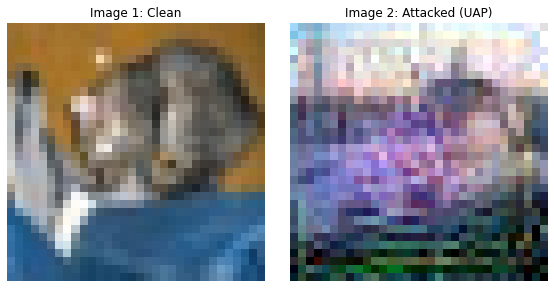

In [ ]:
import numpy as np
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt

tf.compat.v1.disable_eager_execution()

print("Loading data and models for visual demo...\n")
mixed_test_X = np.load('mixed_test_X.npy')
clean_test_Y = np.load('mixed_test_Y.npy') 
test_attack_labels = np.load('test_attack_labels.npy')

prn = tf.keras.models.load_model('trained_prn.h5', compile=False)
honeypot_model = tf.keras.models.load_model('models/cifar_model.h5', compile=False)
joint_model = tf.keras.models.load_model('trained_joint_model.h5', compile=False)

svm_detector = PerturbationDetectorSVM(prn, device=None, keep_coeffs=8) 
svm_detector.pipeline = joblib.load('svm_detector.joblib')
svm_detector.is_trained = True

clean_idx = np.where(test_attack_labels == 0)[0][0]
uap_idx = np.where(test_attack_labels == 1)[0][0]

demo_clean_img = mixed_test_X[clean_idx : clean_idx + 1]
demo_clean_label = np.argmax(clean_test_Y[clean_idx])

demo_uap_img = mixed_test_X[uap_idx : uap_idx + 1]
demo_uap_label = np.argmax(clean_test_Y[uap_idx])

def run_clean_visual_demo(clean_img, clean_label, uap_img, uap_label):
    
    def process_image(img):
        base_pred = np.argmax(honeypot_model.predict(img))
        svm_flag = svm_detector.predict(img)[0]
        
        if svm_flag == 0:
            final_pred = np.argmax(honeypot_model.predict(img))
            route = "Honeypot"
        else:
            final_pred = np.argmax(joint_model.predict(img))
            route = "PRN -> Honeypot"
            
        return base_pred, svm_flag, route, final_pred

    c_base, c_flag, c_route, c_final = process_image(clean_img)
    u_base, u_flag, u_route, u_final = process_image(uap_img)

    print("\n[IMAGE 1: NORMAL CLEAN IMAGE]")
    print(f"True Class:          {clean_label}")
    print(f"Without Defense:     Class {c_base}")
    print(f"SVM Detects Attack?  {'Yes' if c_flag == 1 else 'No'}")
    print(f"Routed to:           {c_route}")
    print(f"Pipeline Output:     Class {c_final}")

    u_base_str = "CORRECT" if u_base == uap_label else "INCORRECT"
    u_final_str = "CORRECT" if u_final == uap_label else "INCORRECT"
    
    print("\n[IMAGE 2: ATTACKED IMAGE (UAP)]")
    print(f"True Class:          {uap_label}")
    print(f"Without Defense:     Class {u_base} [{u_base_str}]")
    print(f"SVM Detects Attack?  {'Yes' if u_flag == 1 else 'No'}")
    print(f"Routed to:           {u_route}")
    print(f"Pipeline Output:     Class {u_final} [{u_final_str}]")

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    disp_clean = np.clip(clean_img[0], 0.0, 1.0)
    disp_uap = np.clip(uap_img[0], 0.0, 1.0)

    # Left Image
    axes[0].imshow(disp_clean)
    axes[0].axis('off')
    axes[0].set_title("Image 1: Clean")

    # Right Image
    axes[1].imshow(disp_uap)
    axes[1].axis('off')
    axes[1].set_title("Image 2: Attacked (UAP)")

    plt.tight_layout()
    plt.show()

run_clean_visual_demo(demo_clean_img, demo_clean_label, demo_uap_img, demo_uap_label)